In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[ 4.39381833, -0.71134217],
       [ 5.74965629, -0.7135565 ],
       [-5.90946287,  7.505476  ],
       ...,
       [-9.09011046,  7.95027117],
       [ 3.47219926,  0.39264381],
       [ 4.18303036, -0.06802999]], shape=(1000, 2))

In [5]:
y

array([2, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 1, 0, 1, 2,
       0, 0, 0, 1, 2, 2, 1, 1, 1, 1, 2, 0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2,
       1, 1, 2, 0, 1, 1, 0, 2, 0, 2, 2, 2, 1, 1, 2, 2, 1, 2, 0, 1, 1, 0,
       0, 0, 2, 1, 2, 0, 0, 2, 2, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 2, 2, 1, 0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 2, 0, 2, 2, 1, 0, 1, 0, 2, 2, 1, 2, 0, 1, 2, 0, 1, 1, 1,
       0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 1, 2, 1, 1, 0, 1, 0,
       1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 2, 1, 2, 0, 0, 2, 1, 1,
       1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 2, 2, 1,
       1, 0, 2, 0, 1, 0, 2, 2, 1, 1, 2, 0, 1, 0, 1, 2, 0, 0, 1, 2, 0, 2,
       2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 2, 2, 2, 2, 1, 1,
       0, 1, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1,
       2, 2, 1, 0, 1, 0, 0, 1, 1, 1, 2, 0, 1, 0, 1, 0, 1, 1, 1, 1, 2, 2,
       0, 1, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 1, 2, 2,

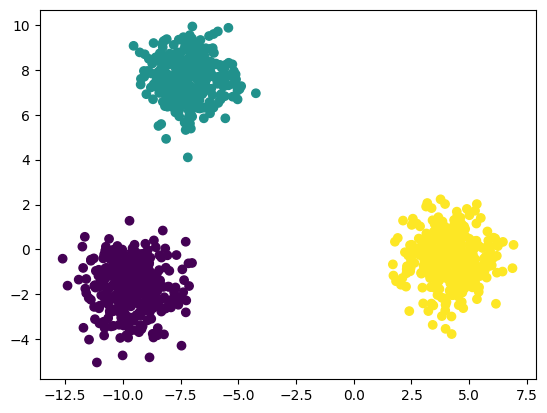

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [13]:
wcss

[1340.0000000000005,
 619.6288912443742,
 55.39255969356644,
 46.39173447387099,
 39.077967514271535,
 37.02879604850571,
 32.63859963096625,
 24.943567768147386,
 22.613909235840918,
 20.932664692838728]

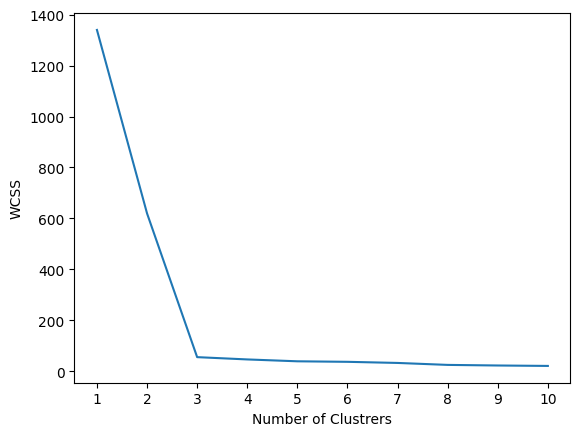

In [14]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([0, 1, 0, 1, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 2, 2, 0, 2,
       1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 2, 0, 1, 0, 2, 2,
       1, 0, 1, 2, 0, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1,
       0, 0, 2, 1, 0, 0, 1, 2, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 1, 2, 0, 2, 2, 1, 2, 0, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 1, 1, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 1, 2, 2,
       0, 2, 2, 1, 0, 0, 1, 2, 0, 2, 2, 1, 1, 1, 0, 0, 2, 0, 2, 1, 0, 1,
       0, 2, 2, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, 1, 0, 1, 1, 1, 0, 2, 2,
       0, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 0, 1, 2, 0, 0, 0, 1, 0, 0,
       1, 2, 2, 2, 0, 2, 2, 1, 0, 1, 2, 0, 2, 1, 2, 0, 1, 1, 2, 0, 2, 1,
       2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 0, 0, 1, 1, 1, 0, 1, 0, 1, 2,
       1, 0, 2, 0, 2, 1, 2, 2, 1, 0, 1, 2, 1, 1, 2, 2, 2, 1, 2, 0, 1, 1,
       2, 1, 1, 0, 1, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 2, 0, 1, 0, 1, 0, 2, 1, 0,

In [17]:
y_pred=kmeans.predict(X_test_scaled)

In [18]:
y_pred

array([2, 1, 1, 1, 2, 0, 2, 1, 0, 1, 0, 0, 0, 1, 2, 1, 1, 2, 0, 0, 0, 1,
       0, 0, 1, 0, 2, 2, 2, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1,
       2, 0, 1, 0, 2, 2, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 0,
       0, 1, 2, 2, 0, 1, 0, 0, 2, 0, 2, 2, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0,
       2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 0, 1, 0, 2, 0,
       0, 0, 0, 0, 1, 2, 1, 1, 0, 0, 2, 0, 1, 2, 2, 1, 0, 2, 1, 2, 2, 1,
       2, 2, 1, 2, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 0, 2, 0, 2, 0, 1,
       1, 2, 0, 1, 2, 2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 1, 0, 0, 2, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 2, 2, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 0, 1, 0, 0, 1, 2, 2, 2,
       0, 0, 2, 0, 1, 0, 2, 0, 1, 0, 0, 2, 2, 1, 0, 0, 0, 1, 2, 1, 0, 1,
       2, 0, 0, 2, 0, 0, 0, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0,
       0, 0, 1, 1, 2, 1, 1, 0, 1, 2, 2, 2, 2, 2, 1,

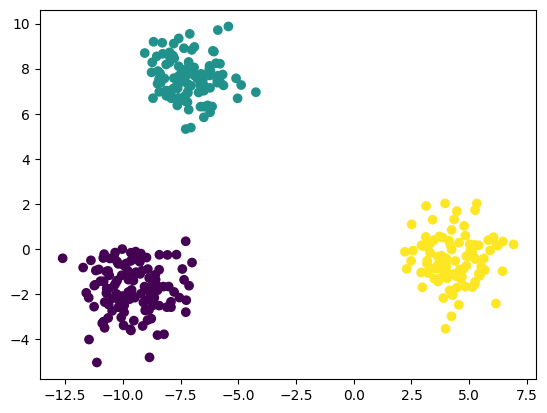

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [20]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [21]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from kneed import KneeLocator

In [23]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [24]:
kl.elbow

np.int64(3)

In [25]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [24]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [26]:
silhouette_coefficients

[0.7526367077572678,
 0.7957616624805482,
 0.6547577732815691,
 0.4977034496977808,
 0.31437969906882635,
 0.3222558169156503,
 0.33036604035680517,
 0.3293774105047836,
 0.3091503150237089]

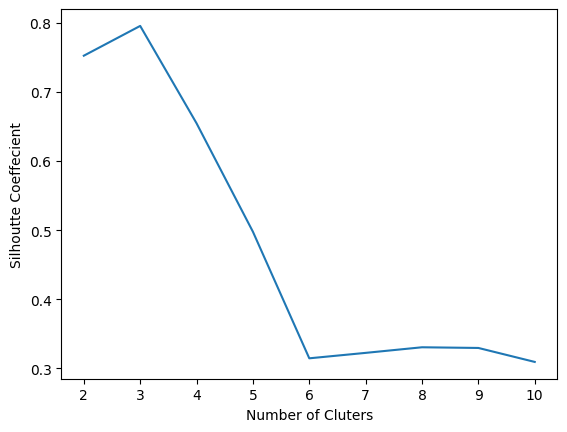

In [27]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()